# [기초-실습] 통계 분석의 첫걸음: 통계학·모집단·기술통계

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [9]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Password:
sudo: a password is required
Password:

: 

: 

In [1]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import matplotlib.font_manager as fm

fm.fontManager.addfont('/System/Library/Fonts/Supplemental/AppleGothic.ttf')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


# 문제 1. 기초통계량 계산

**📘 문제**

- 온라인 쇼핑몰 고객 1,000명을 대상으로 1점부터 10점 사이의 만족도 조사를 실시했습니다.
  이 데이터를 바탕으로 고객 만족도의 **중심 경향성**과 **분포 특성**을 파악해 봅시다.

In [2]:
# 데이터 생성
np.random.seed(2025)
satisfaction = np.random.normal(7.5, 1.5, 1000)
satisfaction = np.clip(satisfaction, 1, 10)
df1 = pd.DataFrame({'score': satisfaction})
print(df1)

        score
0    7.361415
1    8.601428
2    5.341677
3    6.504867
4    7.348908
..        ...
995  5.588019
996  7.039904
997  6.907670
998  5.075884
999  8.446012

[1000 rows x 1 columns]


**📌 아래를 수행해 보세요:**

- 평균, 중앙값, 최빈값, 표준편차를 계산해 봅시다.
- 히스토그램을 그리고 평균과 중앙값 선으로 표시해 봅시다.
- 데이터의 분포 형태를 해석한 후, 마케팅 전략 수립에 어떻게 활용할 수 있을지 생각해 봅시다.

평균:  7.428689549278887
중앙값:  7.421730663868805
최빈값:  10.0


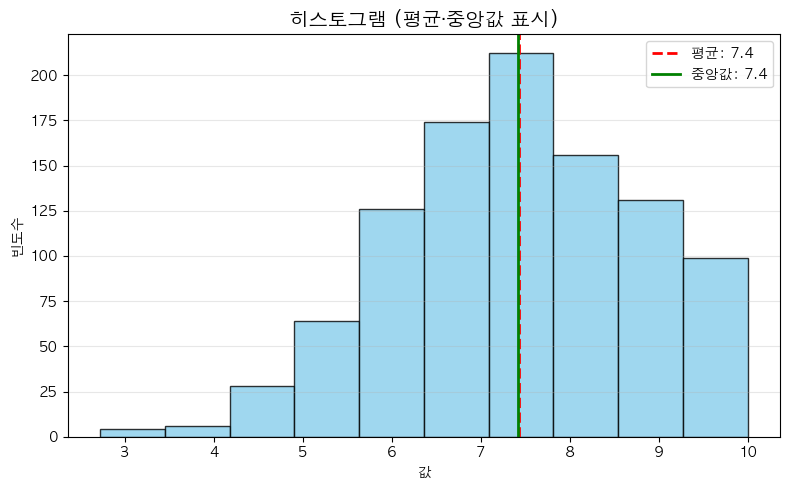

In [ ]:
# 아래를 수행해 보세요:
# [문제 1] 여기에 코드를 작성해주세요.
mean = df1['score'].mean()
print("평균: ", mean)
median = df1['score'].median()
print("중앙값: ", median)
mode = df1['score'].mode()[0]
print("최빈값: ", mode)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))

plt.hist(
    df1['score'],
    bins=10,
    color='skyblue',
    edgecolor='black',
    alpha=0.8,
)

# ── 평균 / 중앙값 세로선 ──
plt.axvline(mean, color='red', linestyle='--', linewidth=2,
            label=f'평균: {mean:.1f}')
plt.axvline(median, color='green', linestyle='-', linewidth=2,
            label=f'중앙값: {median:.1f}')

# ── 라벨 / 제목 / 범례 ──
plt.title('히스토그램 (평균·중앙값 표시)', fontsize=14)
plt.xlabel('값')
plt.ylabel('빈도수')
plt.legend()                    # 평균/중앙값 선 설명 표시
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

1. 평균과 중앙값 사이의 차이는 어느 정도인가요?
   - 두 값이 비슷하다면, 이 데이터는 어떤 분포 형태일 가능성이 있을까요? (예: 대칭형, 정규분포 등)
   - 두 값의 차이가 크다면, 그 이유는 무엇일까요?
   - 어떤 값들이 평균을 끌어내리거나 끌어올렸을까요?

2. 최빈값이 평균보다 낮은 경우, 낮은 점수를 준 고객이 많다는 뜻일 수 있습니다. 이 경우 데이터 분포는 어느 쪽으로 치우쳐 있을까요?
   - 반대로 최빈값이 평균보다 높은 경우에는 어떤 해석이 가능할까요? 이럴 때 분포가 어떻게 달라질 수 있을까요?

3. 이 데이터를 바탕으로 고객 만족도를 높이기 위한 마케팅 전략에는 어떤 것들이 있을까요?

### **데이터를 어떻게 읽을까요?**
#### *[문제 1] 여기에 의견을 작성해주세요.*
**1. 평균과 중앙값은 거의 동일한 수준이다.**
- 두 값이 비슷하다면 이 데이터는 정규분포일 가능성이 높다.
- 최빈값이 10이므로 최빈값이 평균을 끌어올렸을것으로 추정된다.

**2. 최빈값이 평균보다 낮은 경우 데이터 분포는 오른쪽으로 치우쳐져 있고, 왜도는 0보다 작다.**
- 최빈값이 평균보다 높은 경우 데이터 분포는 왼쪽으로 치우쳐져 있고, 왜도는 0보다 크다.

**3. 대체적으로 높은 점수를 준 고객이 많았기에 높은 점수를 준 고객을 유치하기 위한 마케팅 전략을 세우면 좋을 것 같다.**


# 문제 2. 평균 vs 중앙값 비교

**📘 문제**

- A지역과 B지역의 연봉 데이터를 비교해 봅시다.
- B 지역에는 일부 고소득자가 포함되어 있습니다.

In [6]:
# 데이터 생성
np.random.seed(2025)

# A 지역: 평균 300, 표준편차 50
region_a = np.random.normal(300, 50, 100)

# B 지역: 일반 소득자 + 극단적인 고소득자 포함
region_b = np.concatenate([
    np.random.normal(280, 40, 95),    # 일반 소득자 95명
    np.random.normal(1500, 200, 5)    # 고소득자 5명
])

df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})

display(df2)

,region,salary
0,A,295.380491
1,A,336.714279
2,A,228.055899
3,A,266.828899
4,A,294.963596
...,...,...
195,B,1668.477201
196,B,1581.119661
197,B,1637.123979
198,B,1709.906631


**📌 아래를 수행해 보세요:**

- 각 지역의 평균 연봉과 중앙값을 구해 봅시다.
- 지역별 박스플롯(Boxplot)을 그려서 분포의 차이를 시각적으로 확인해 봅시다.

A지역의 평균 연봉: 292.5066374901889 만원
A지역의 중앙값: 294.32448331703154 만원
B지역의 평균: 347.5949090667186 만원
B지역의 중앙값: 287.34748777411573 만원


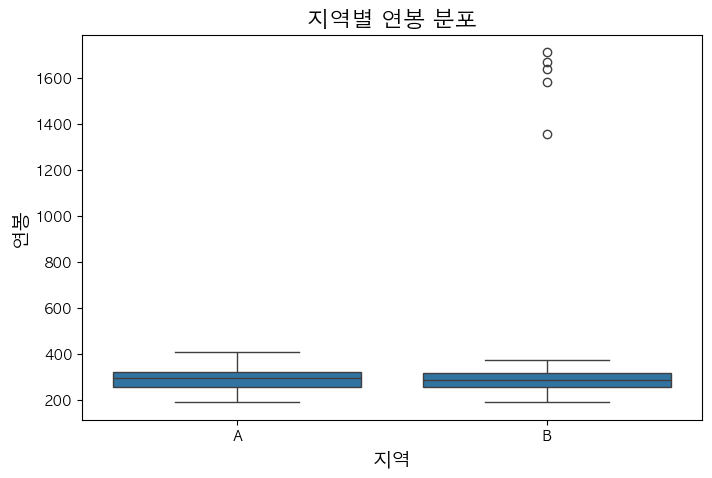

In [23]:
# 아래를 수행해 보세요:
# [문제 2] 여기에 코드를 작성해주세요.
mean_a = region_a.mean()
median_a = np.median(region_a)   # numpy 배열은 메서드가 아니라 함수로 중앙값을 구함
print("A지역의 평균 연봉:", mean_a, "만원")
print("A지역의 중앙값:", median_a, "만원")

mean_b = region_b.mean()
median_b = np.median(region_b)
print("B지역의 평균:", mean_b, "만원")
print("B지역의 중앙값:", median_b, "만원")


plt.figure(figsize=(8,5))

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(data=df2, x='region', y='salary')

plt.title('지역별 연봉 분포', fontsize = 16)
plt.xlabel('지역',fontsize=14)
plt.ylabel('연봉',fontsize=14)
plt.show()


**🧠 데이터를 어떻게 읽을까요?**

1. A 지역과 B 지역의 평균 연봉은 어떻게 다른가요?
   - 두 지역의 평균 차이가 의미하는 바는 무엇인가요?
   - 고소득자가 있는 지역의 평균은 어떤 영향을 받을까요?

2. 중앙값은 어떠한가요?
   - 평균과 비교했을 때, 중앙값이 더 낮거나 높다면 어떤 해석이 가능할까요?

3. 극단값(고소득자)의 영향은 어디에서 더 크게 나타날까요?
   - 평균과 중앙값 중 어떤 지표가 극단값에 더 민감한가요?

4. 박스플롯을 통해 어떤 점을 관찰할 수 있나요?
   - 이상치(Outlier)는 어떻게 표시되나요?
   - 두 지역의 분포 폭(사분위 범위)은 어떻게 다른가요?

5. 평균만 보고 판단했을 때 생길 수 있는 오해는 무엇인가요?
   - 어떤 경우에는 중앙값이 더 유용한 지표일 수 있을까요?

### **데이터를 어떻게 읽을까요?**
#### *[문제 2] 여기에 의견을 작성해주세요.*
**1. A지역의 평균 연봉은 292.5066374901889 만원이며 B지역의 평균 연봉은 347.5949090667186 만원이다.**
- A지역보다 B지역에 고연봉자가 많다.
- 끌어올림의 영향을 받을것이다.

**2. A지역의 연봉 중앙값은 294.32448331703154 만원이며 B지역의 연봉 중앙값은 287.34748777411573 만원이다.**
- 평균과 비교했을때 중앙값이 더 낮다면 일부 높은 값들이 평균을 끌어올렸음다고 해석할 수 있으며, 평균과 비교했을때 중앙값이 더 높다면 일부 낮은 값들이 평균을 끌어내렸다고 해석할 수 있다.

**3. 평균에서 더 크게 나타날것이다.**
- 중앙값보다 평균이 더 민감하다.

**4.**
- 이상치는 위쪽 동그라미로 표시된다.
- 두 지역의 분포 폭 자체는 비슷하거나 B가 아주 조금 더 작게 관측됐다.

**5. 평균만 보고 판단했을때 무작정 B지역에 잘 버는 사람의 수가 많을것이다. 라고 오해가 생길 수 있다.**
- 연봉과 같이 분포가 한쪽으로 치우칠 수 있는 경우에는 중앙값이 더 유용한 지표일 수 있다.


# 문제 3. 이상값과 분산 비교

**📘 문제**

- 1반과 2반의 시험 점수 분포를 비교해 봅시다.
- 2반에는 극단적인 이상값(예: 부정행위로 0점)이 포함되어 있습니다.

In [24]:
# 데이터 생성
np.random.seed(2025)  # 재현 가능성을 위해 시드 고정

# 1반: 평균 75, 표준편차 8
class1 = np.random.normal(75, 8, 30)

# 2반: 일반 학생 + 이상값(0점, 130점)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),  # 일반 학생
    [0, 130]                       # 극단적인 이상값
])

df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})

**📌 아래를 수행해 보세요:**

1. 각 반의 평균, 표준편차, 최소/최대값을 계산해 봅시다.
2. 박스플롯을 사용하여 두 반의 분포 차이를 시각적으로 비교해 봅시다.
3. 이상값이 통계 지표에 어떤 영향을 주는지 생각해 봅시다.

A반
평균:  75.72431585669382 점
표준편차:  6.944000575108353 점
최소/최대값:  60.68541562198489 점, 92.17589258628496 점

B반
평균:  73.72884842544566 점
표준편차:  21.965315425959837 점
최소/최대값:  0.0 점, 130.0 점


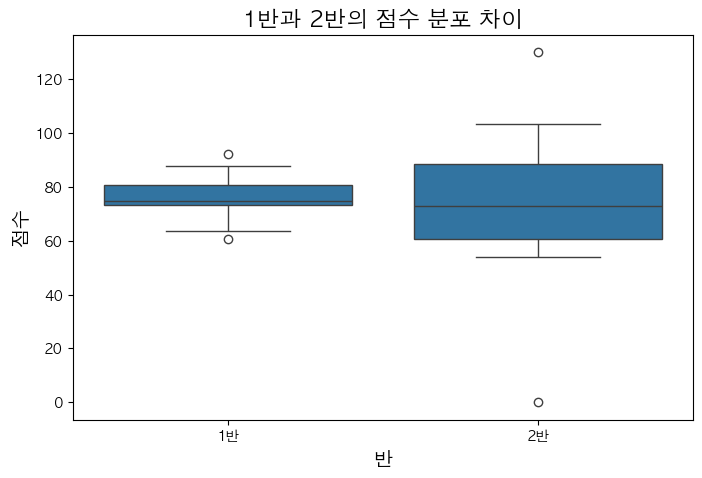

In [ ]:
# 아래를 수행해 보세요:
# [문제 3] 여기에 코드를 작성해주세요.
mean_1 = class1.mean()
mean_2 = class2.mean()
std_1 = np.std(class1)
std_2 = np.std(class2)
min_1 = np.min(class1)
min_2 = np.min(class2)
max_1 = np.max(class1)
max_2 = np.max(class2)

print("A반")
print("평균: ", mean_1,"점")
print("표준편차: ", std_1,"점")
print("최소/최대값: ", min_1, "점,", max_1,"점")
print("\nB반")
print("평균: ", mean_2,"점")
print("표준편차: ", std_2,"점")
print("최소/최대값: ", min_2, "점,", max_2,"점")


plt.figure(figsize=(8,5))

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(data=df3, x='class', y='score')

plt.title('1반과 2반의 점수 분포 차이', fontsize = 16)
plt.xlabel('반',fontsize=14)
plt.ylabel('점수',fontsize=14)
plt.show()



**🧠 데이터를 어떻게 읽을까요?**

1. 어떤 반의 점수 분산이 더 크고, 왜 그럴까요?
   - 점수 분포의 퍼짐 정도는 어떤 지표로 확인할 수 있을까요?
   - 이상값이 포함되면 표준편차나 범위는 어떻게 달라질까요?

2. 이상값이 있는 반의 평균은 어떤 영향을 받았나요?
   - 극단적으로 낮거나 높은 점수가 평균을 끌어내리거나 끌어올렸나요?
   - 평균과 중앙값의 차이가 의미하는 바는 무엇인가요?

3. 박스플롯을 통해 이상값은 어떻게 드러나나요?
   - 이상값(outlier)은 박스플롯에서 어떤 형태로 나타나나요?
   - 두 반의 박스(사분위 범위)는 어떻게 다르게 보이나요?

4. 평균만 보고 평가했을 때 생길 수 있는 오해는 무엇인가요?
   - 예를 들어, 교사가 평균 점수만 보고 2반이 부족하다고 판단한다면?
   - 중앙값이나 표준편차 같은 지표와 함께 분석하는 것은 왜 중요할까요?

### **데이터를 어떻게 읽을까요?**
#### *[문제 3] 여기에 의견을 작성해주세요.*

**1.**
- 점수 분포의 퍼짐정도는 표준편차를 통해 할 수 있다. 그렇기에 2반이 점수 분산이 더 크다.
- 이상값이 포함되면 표준편차와 범위는 늘어나게 된다.

**2.**
- 이상값이 있는 반의 평균은 극단적으로 낮은 점수(0점)이 평균을 끌어내렸다.
- 평균과 중앙값의 차이는 이 데이터에 이상값이 얼마나 영향을 주고있는지를 알려주는 것이다.

**3.**
- 이상값은 박스플롯에서 위쪽과 아래쪽에서 동그라미로 나타난다.
- 2반의 박스가 1반의 박스보다 훨씬 크다.

**4.**
- 2반의 평균은 0점이라는 이상값 하나가 끌어내렸기 때문에 평균점수만 보고 2반이 부족하다고 오해가 생길 수 있다.
- 평균은 이상값에 영향을 잘 받기때문에 중앙값과 표준편차와 함께 분석해야 오해가 생기지 않는다.



# 문제 4. IQR 이상값 제거

**📘 문제**

- 앞의 문제에서 2반에는 **극단적인 이상값(예: 매우 낮은 점수)**이 포함되어 있어
  통계 지표, 특히 평균에 큰 영향을 주는 것을 확인했습니다.
- 이번에는 **IQR(사분위 범위)**을 기준으로 이상값을 제거한 뒤, 이상값 제거 전후의 평균을 비교해 봅시다

<br>

**📌 아래를 수행해 보세요:**

- 2반의 점수 데이터를 대상으로 IQR 기준을 사용해 이상값을 판별하고 제거해 봅시다.
- 이상값 제거 전과 제거 후의 평균을 각각 계산해 봅시다.
- 이상값 제거가 평균에 어떤 영향을 주는지 설명해 봅시다.
- 필요하다면 중앙값과도 비교해 봅시다.

In [33]:
# 아래를 수행해 보세요:
# [문제 4] 여기에 코드를 작성해주세요.

# 1. IQR 계산 (2반 데이터: class2)
q1 = np.percentile(class2, 25)
q3 = np.percentile(class2, 75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"이상값 기준: {lower:.2f} 미만 또는 {upper:.2f} 초과")

# 2. 이상값 판별
outliers = class2[(class2 < lower) | (class2 > upper)]
print("이상값:", outliers)

# 3. 이상값 제거
class2_clean = class2[(class2 >= lower) & (class2 <= upper)]

# 4. 제거 전후 평균 비교
mean_before = class2.mean()
mean_after = class2_clean.mean()
median_before = np.median(class2)

print(f"\n제거 전 평균: {mean_before:.2f}","점")
print(f"제거 후 평균: {mean_after:.2f}","점")
print(f"중앙값(원래): {median_before:.2f}","점")



Q1: 60.75, Q3: 88.37, IQR: 27.61
이상값 기준: 19.33 미만 또는 129.79 초과
이상값: [  0. 130.]

제거 전 평균: 73.73 점
제거 후 평균: 74.35 점
중앙값(원래): 73.00 점


**🧠 데이터를 어떻게 읽을까요?**

1. 이상값 제거 전후 평균은 어떻게 달라졌나요?
   - 평균이 중앙값에 가까워졌나요?
   - 이상값 제거가 평균에 어떤 방향으로 영향을 주었나요?

2. 왜 IQR을 기준으로 이상값을 판단할까요?
   - IQR은 데이터를 어떻게 나누고, 어떤 방식으로 이상값을 정의하나요?
   - 평균이나 표준편차 기준과 비교했을 때 어떤 점이 더 강건할까요?

3. 이상값은 언제 제거하고, 언제 유지해야 할까요?
   - 분석 목적에 따라 이상값은 중요한 정보가 될 수 있습니다.

4. 중앙값과 평균은 각각 어떤 상황에서 더 유용한 지표인가요?
   - 이상값이 있을 때 어떤 지표가 더 신뢰할 수 있나요?
   - 두 지표를 함께 보면 어떤 장점이 있을까요?

### 데이터를 어떻게 읽을까요?
#### [문제 4] 여기에 의견을 작성해주세요.
**1.**
- 평균이 중앙값에서 멀어졌다.
- 평균을 높이는 방향으로 영향을 주었다.

**2.**
- IQR은 데이터를 q1, q3 기준으로 나누며 그 기준에서 일정 구간 이상 이하이면 이상값으로 정의한다.
- 평균이나 표준편차는 너무 낮거나 너무 높은 값이 있으면 영향을 받지만 IQR은 그 너무 낮거나 너무 높은 값을 이상값으로 정의하기 때문에 더 정확하게 분석할 수 있다.

**3.**
- 이상값은 실제로 오류일때는 제거하는 게 맞지만, 실제로 의미있는 데이터일 경우 유지해야한다.

**4.**
- 이상값이 있을땐 중앙값을 더 신뢰할 수 있다.
- 평균과 중앙값을 함께 보면 분포가 치우쳤는지를 알 수 있다.

# 문제 5. 변수 유형 분류

**📘 문제**

- 아래 데이터에서 변수의 유형(연속형, 범주형, 이산형 등)을 구분해 봅시다.
- 변수의 의미를 고려하여 어떤 분석 방식이 적절한지도 함께 생각해 봅시다.

In [3]:
# 데이터 생성
np.random.seed(2025)
df5 = pd.DataFrame({
    'age': np.random.randint(18, 65, 200),
    'coffee_type': np.random.choice(['아메리카노', '라떼', '카페모카'], 200),
    'size': np.random.choice(['Small', 'Medium', 'Large'], 200),
    'price': np.random.normal(4500, 500, 200),
    'satisfaction': np.random.randint(1, 6, 200)
})

**📌 아래를 수행해 보세요:**

1. 각 변수의 데이터 타입을 확인해 봅시다.

2. 변수의 의미를 기준으로 다음 중 어떤 유형에 해당하는지 분류해 봅시다.
   - 연속형 (numeric-continuous)
   - 이산형 (numeric-discrete)
   - 범주형 (categorical)
   - 서열형 범주 (ordinal-categorical)

In [4]:
# 아래를 수행해 보세요:
# [문제 5] 여기에 코드를 작성해주세요.
# 1. 데이터 타입 확인
print(df5.dtypes)

# 2. 변수 유형 분류 (판단 결과를 주석/설명으로 정리)
print("""
age          : 이산형 수치 (정수 단위 나이)
coffee_type  : 범주형(명목형) - 순서 없음
size         : 서열형 범주 (Small < Medium < Large)
price        : 연속형 수치
satisfaction : 서열형 범주 (1~5 평점, 순서는 있지만 등간성 보장 안됨)
""")

age               int64
coffee_type      object
size             object
price           float64
satisfaction      int64
dtype: object

age          : 이산형 수치 (정수 단위 나이)
coffee_type  : 범주형(명목형) - 순서 없음
size         : 서열형 범주 (Small < Medium < Large)
price        : 연속형 수치
satisfaction : 서열형 범주 (1~5 평점, 순서는 있지만 등간성 보장 안됨)



**🧠 데이터를 어떻게 읽을까요?**

1. 숫자처럼 보이지만 사실은 범주형 또는 서열형으로 해석하는 변수가 있다면 무엇일까요?

2. 변수 유형에 따라 적절한 분석 방법이나 시각화 방식은 어떻게 달라질까요?

### 데이터를 어떻게 읽을까요?
#### [문제 5] 여기에 의견을 작성해주세요.

**1.**
- satisfaction이다.

**2.**
- 연속형 변수는 평균/표준편차로 분석하고 히스토그램으로 시각화 해야하고, 범주형(명목형)변수는 최빈값과 비율로 분석하고 막대그래프로 시각화 해야하며, 서열형 변수는 중앙값으로 분석해야한다.


# 문제 6. 상관관계 분석

**📘 문제**

- 이번에는 변수들 간의 **관계(상관관계)**를 분석해 봅시다.
- 특히 기온(`temp`), 습도(`humidity`), 판매(`sales`) 변수 간의 관계를 수치와 시각화로 살펴보겠습니다.

In [3]:
# 데이터 생성
np.random.seed(202)

temp = np.random.normal(25, 5, 100)
humidity = np.random.normal(60, 10, 100)
sales = temp * 10 - humidity * 2 + np.random.normal(0, 20, 100) + 200

df6 = pd.DataFrame({'temp': temp, 'humidity': humidity, 'sales': sales})

**📌 아래를 수행해 보세요:**

1. 아래의 기온, 습도, 매출 데이터를 사용하여 상관계수 행렬을 출력해 봅시다.

2. 페어플롯(pairplot)을 이용하여 변수 간의 관계를 시각화해 봅시다.

              temp  humidity     sales
temp      1.000000 -0.115936  0.906593
humidity -0.115936  1.000000 -0.390105
sales     0.906593 -0.390105  1.000000


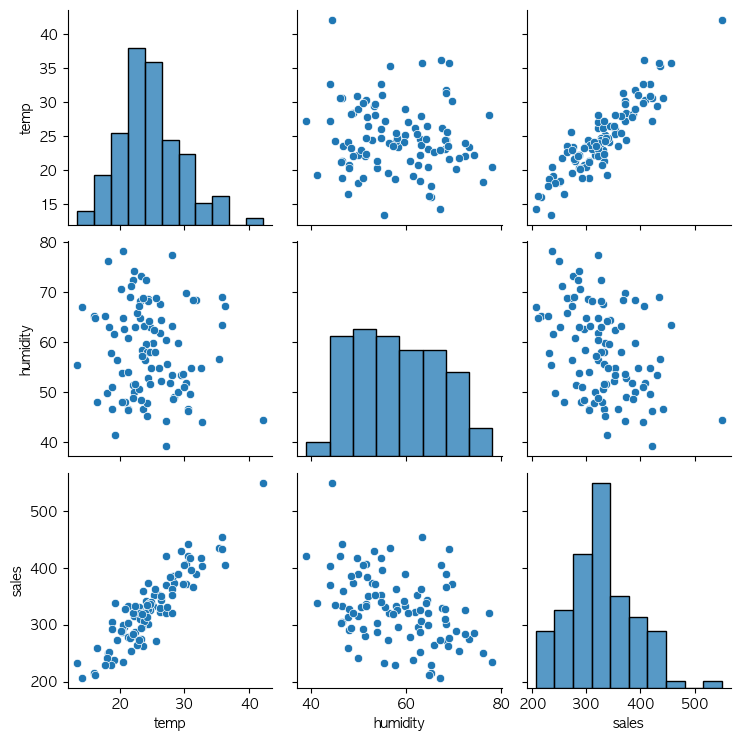

In [4]:
# 아래를 수행해 보세요:
# [문제 6] 여기에 코드를 작성해주세요.
# 1. 상관계수 행렬
corr_matrix = df6.corr()
print(corr_matrix)

# 2. 페어플롯
sns.pairplot(df6)
plt.show()



**🧠 데이터를 어떻게 읽을까요?**

1. 출력된 상관계수 행렬을 보고,
   - 어떤 변수와 `sales` 간의 상관계수가 가장 높은가요?
   - 어느 쌍이 **양의 상관관계**, 어느 쌍이 **음의 상관관계**인가요?

2. 페어플롯에서
   - 어떤 변수 쌍은 **직선 형태**로 관계가 보이나요?
   - 어떤 변수 쌍은 **분산이 크거나 패턴이 없는**가요?

3. **상관관계가 반드시 인과관계를 의미하지는 않습니다.**
   - 온도와 매출에 상관관계가 있다고 해서, 온도가 매출을 직접적으로 증가시킨다고 볼 수 있을까요?

4. 이 데이터를 바탕으로 어떤 **추가 가설**이나 **실험 설계**를 생각해볼 수 있을까요?

### 데이터를 어떻게 읽을까요?
#### [문제 6] 여기에 의견을 작성해주세요.
1.
- temp 변수가 0.906593으로 가장 높다.
- 양의 상관관계 : (temp,sales) 음의 상관관계 : (temp, humidity), (sales, humidity)

2. 
- (temp,sales)가 직선 형태로 관계가 보인다.
- (temp, humidity), (sales, humidity)가 분산이 크거나 패턴이 없는걸로 보인다.

3. 
- 온도와 매출에 상관관계가 있다고 해서, 온도가 매출을 직접적으로 증가시키는 인과관계는 있다고 확신할 수 없기 때문에 직접적으로 증가시킨다고 볼 수는 없다.

4. 
- 다른 변수를 더 추가해 더 세부적으로 분석해볼수있다.

# 문제 7. 범주형 변수 시각화

**📘 문제**

- 앞에서는 수치형 변수의 분포를 시각화하고, 변수 간의 관계도 살펴보았습니다.
- 이번에는 범주형 변수인 커피 음료 데이터를 시각화해 봅시다.
- 어떤 종류가 많이 판매되었는지 빈도 분석을 통해 알아보겠습니다.

In [5]:
# 데이터 생성
df7 = pd.DataFrame({
    'drink': np.random.choice(['아메리카노', '라떼', '콜드브루'], 300)
})

**📌 아래를 수행해 보세요:**

1. 아래 데이터에서 drink 변수는 판매된 음료의 종류를 나타냅니다.
   - 각각 몇 개씩 판매되었는지 빈도표를 만들어 확인해 봅시다.
   - **막대그래프(bar plot)**를 그려서 결과를 시각화해 봅시다.

2. 시각화 결과를 보고,
   - 어떤 음료가 가장 많이 팔렸는지 파악해 봅시다.
   - 이 결과를 마케팅 전략에 어떻게 활용할 수 있을지 생각해 봅시다.

drink
콜드브루     108
아메리카노     97
라떼        95
Name: count, dtype: int64


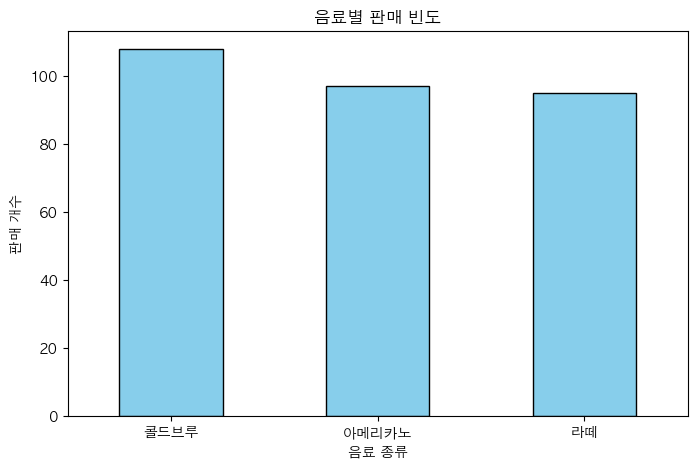

In [7]:
# 아래를 수행해 보세요:
# [문제 7] 여기에 코드를 작성해주세요.
# 1. 빈도표
freq = df7['drink'].value_counts()
print(freq)

# 2. 막대그래프
plt.figure(figsize=(8,5))
freq.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('음료별 판매 빈도')
plt.xlabel('음료 종류')
plt.ylabel('판매 개수')
plt.xticks(rotation=0)
plt.show()


**🧠 데이터를 어떻게 읽을까요?**

1. 출력된 빈도표와 막대그래프를 보면, 어떤 음료가 가장 많이 판매되었나요?
   - 판매량이 가장 많은 음료는?
   - 그 다음으로 인기 있는 음료는?

2. 이 결과는 어떤 마케팅 전략에 활용할 수 있을까요?
   - 가장 많이 팔린 음료를 주력 상품으로 홍보해야 할까요?
   - 판매량이 적은 음료를 프로모션 대상으로 삼는 것은 어떨까요?

3. 막대그래프는 왜 범주형 변수에 적합할까요?
   - `drink`처럼 종류가 명확히 나뉘는 변수를 분석할 때 어떤 점이 중요한가요?

4. 범주형 변수 분석 시 주의할 점은?

### 데이터를 어떻게 읽을까요?
#### [문제 7] 여기에 의견을 작성해주세요.

1. 
- 콜드브루가 판매량이 108잔으로 가장 많다.
- 그 다음으로는 아메리카노가 97잔으로 인기있다.

2. 
- 가장 많이 팔린 음료를 주력 상품으로 홍보하는 것도 좋고, 판매량이 적은 음료는 세일이나 묶음판매 프로모션을 통해 마케팅을 할 수 있을거같다.

3. 
- 범주에는 순서나 연속성이 없기 때문에 히스토그램보다 막대그래프가 더 적합하다.

4. 
- 범주가 너무 많으면 그래프가 복잡해져 보기 어렵고, 표본이 작으면 우연한 차이를 실제 차이로 오인할 수 있기에 주의해야한다.

# 문제 8. 요일별 평균 비교

**📘 문제**

- 이번에는 요일 별 소비 금액 데이터를 분석해 봅시다.
- 각 요일마다 평균 소비 금액이 얼마나 되는지 비교하고,
  **평일과 주말의 소비 패턴 차이**도 함께 살펴보겠습니다.

In [19]:
# 데이터 생성
df8 = pd.DataFrame({
    'day': np.random.choice(['월', '화', '수', '목', '금', '토', '일'], 500),
    'amount': np.random.normal(12000, 2000, 500)
})

**📌 아래를 수행해 보세요:**

1. 아래 데이터를 사용하여 `day`(요일)별 `amount`(소비 금액)의 평균을 계산해 봅시다.
2. 요일별 평균 금액을 **막대그래프(bar plot)**로 시각화해 봅시다.

day
월    11797.596239
화    12361.823681
수    12253.533939
목    11743.153863
금    12447.681325
토    12094.283862
일    11659.263321
Name: amount, dtype: float64


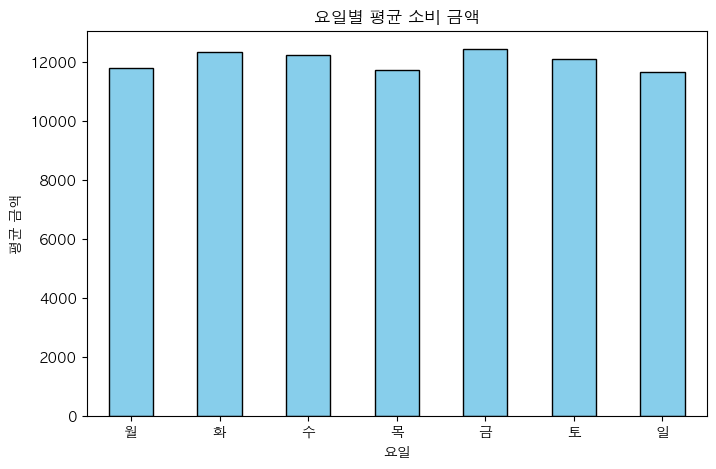

In [20]:
# 아래를 수행해 보세요:
# [문제 8] 여기에 코드를 작성해주세요.
# 1. 요일별 평균
order = ['월', '화', '수', '목', '금', '토', '일']
day_mean = df8.groupby('day')['amount'].mean().reindex(order)
print(day_mean)

# 2. 막대그래프
plt.figure(figsize=(8,5))
day_mean.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('요일별 평균 소비 금액')
plt.xlabel('요일')
plt.ylabel('평균 금액')
plt.xticks(rotation=0)
plt.show()


**🧠 데이터를 어떻게 읽을까요?**

1. 어떤 요일에 소비 금액이 가장 높나요?
   - 주말(토, 일)과 평일(월~금) 중 어떤 쪽의 평균이 더 높은가요?

2. 소비 금액이 적은 요일은 언제인가요? 왜 그럴까요?

3. 이 결과를 어떻게 활용할 수 있을까요?
   - 주말에 더 많은 재고를 준비하거나
   - 평일에 할인 이벤트를 기획하는 등의 운영/마케팅 전략으로 이어질 수 있을까요?

---

> 💬 정리해 보기
>
> - 범주형 변수(요일)별로 연속형 변수(소비 금액)의 평균을 비교하면 소비 패턴을 이해하고 전략을 수립하는 데 유용한 인사이트를 얻을 수 있습니다.

### 데이터를 어떻게 읽을까요?
#### [문제 8] 여기에 의견을 작성해주세요.
1. 금요일의 소비 금액이 가장 높다.
- 주말보다 평일의 평균이 더 높다.

2. 
- 소비 금액이 적은 요일은 일요일이다. 주말의 마지막날이어서 집에서 휴식을 하느라 그럴 수 있을것같다.

3. 
- 평일에 더 많은 재고를 준비하거나, 일요일에도 소비를 유도할 수 있도록 이벤트나 팝업을 운영하는 마케팅을 할 수 있다. 

# 문제 9. 정규분포와 표준편차

**📘 문제**

- 정규분포와 표준편차의 개념을 실제 데이터에 적용해 보겠습니다.
- 정규분포를 따르는 점수 데이터에서 다음을 확인해 봅시다:
  - 평균 ±1σ, 평균 ±2σ 범위에 속한 값들의 비율은 실제로 얼마나 되는가?
  - 이 결과가 이론적인 68-95-99 법칙과 얼마나 유사한지 비교해 봅시다.

<br>

**📌 아래를 수행해 보세요:**

1. 평균이 70, 표준편차가 10인 정규분포 데이터를 1000개 생성해 봅시다.
2. 평균을 중심으로 ±1σ, ±2σ 범위에 포함되는 데이터의 비율을 계산해 봅시다.
3. 결과를 바탕으로 68-95-99 법칙과 비교해 봅시다.

In [21]:
# 아래를 수행해 보세요:
# [문제 9] 여기에 코드를 작성해주세요.
# 1. 데이터 생성
np.random.seed(2025)
scores = np.random.normal(70, 10, 1000)

mean = scores.mean()
std = scores.std()

# 2. ±1σ, ±2σ 범위 비율
within_1sigma = ((scores >= mean - std) & (scores <= mean + std)).mean() * 100
within_2sigma = ((scores >= mean - 2*std) & (scores <= mean + 2*std)).mean() * 100

print(f"±1σ 범위 비율: {within_1sigma:.2f}% (이론값 68%)")
print(f"±2σ 범위 비율: {within_2sigma:.2f}% (이론값 95%)")


±1σ 범위 비율: 68.70% (이론값 68%)
±2σ 범위 비율: 95.00% (이론값 95%)


**🧠 데이터를 어떻게 읽을까요?**

1. ±1σ, ±2σ 범위에 실제로 몇 %의 데이터가 포함되었나요?
2. 이 결과는 68–95–99 법칙과 얼마나 비슷했나요?
3. 표준편차는 왜 중요한 지표인가요?
4. 이 개념이 실제로 어떻게 활용될 수 있을까요?

### 데이터를 어떻게 읽을까요?
#### [문제 9] 여기에 의견을 작성해주세요.

1. 실제로 ±1σ 범위 비율: 68.70%, ±2σ 범위 비율: 95.00% 이렇게 나왔다.
2. 거의 비슷하다.
3. 표준편차는 데이터가 평균 주위에 얼마나 퍼져있는지 나타내기 때문에 중요한 지표이다.
4. 이상거래 탐지나 시험등급컷 설정에 활용될 수 있다.

# 문제 10. 표본 평균 실험

**📘 문제**

- 큰 모집단에서 표본을 여러 번 추출하여 표본 평균의 분포를 비교해봅시다.

<br>

**📌 아래를 수행해 보세요:**

1. 평균이 100, 표준편차가 15인 모집단을 생성합니다.
2. 다음 두 조건에서 각각 1000번씩 표본 평균을 구합니다:
   - 표본 크기 5
   - 표본 크기 50
3. 두 조건의 **표본 평균 분포(histogram)**를 비교합니다.

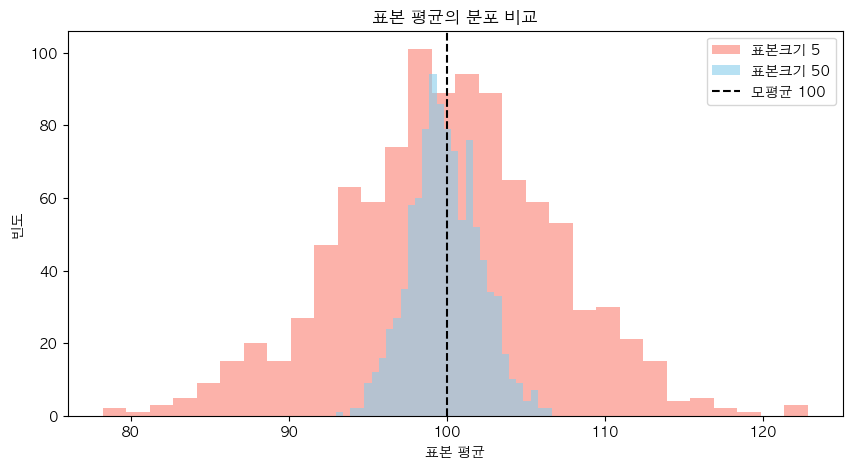

In [22]:
# 아래를 수행해 보세요:
# [문제 10] 여기에 코드를 작성해주세요.
np.random.seed(2025)

# 표본 크기 5, 50 각각 1000번 표본평균 계산
means_5 = [np.random.normal(100, 15, 5).mean() for _ in range(1000)]
means_50 = [np.random.normal(100, 15, 50).mean() for _ in range(1000)]

plt.figure(figsize=(10,5))
plt.hist(means_5, bins=30, alpha=0.6, label='표본크기 5', color='salmon')
plt.hist(means_50, bins=30, alpha=0.6, label='표본크기 50', color='skyblue')
plt.axvline(100, color='black', linestyle='--', label='모평균 100')
plt.title('표본 평균의 분포 비교')
plt.xlabel('표본 평균')
plt.ylabel('빈도')
plt.legend()
plt.show()



**🧠 데이터를 어떻게 읽을까요?**

1. **표본 크기가 다를 때 표본 평균 분포는 어떻게 달라졌나요?**
2. **왜 표본 크기가 중요할까요?**
3. **이 개념은 실제로 어디에 활용될 수 있을까요?**

### 데이터를 어떻게 읽을까요?
#### [문제 10] 여기에 의견을 작성해주세요.

1. 표본 크기가 클수록 표본 평균 분포는 작게 나타난다.
2. 표본 크기가 클수록 표본평균이 모평균에 가까워지기 때문이다.
3. 여론조사에 활용될 수 있다.

# 문제 11. 단순 선형 회귀 분석

**📘 문제**

- 공부 시간과 성적 간의 관계를 회귀 분석으로 확인해봅시다.

In [23]:
# 데이터 생성
from sklearn.linear_model import LinearRegression

np.random.seed(505)
study_time = np.random.normal(5, 2, 100)
score = 50 + study_time * 8 + np.random.normal(0, 5, 100)
df11 = pd.DataFrame({'study_time': study_time, 'score': score})

**📌 아래를 수행해 보세요:**

1. 공부 시간(`study_time`)과 성적(`score`)간의 관계를 단순 선형 회귀모델로 분석합니다.
2. 회귀 모델을 학습하고, 기울기(계수)와 절편을 출력해 봅시다.
3. 산점도 위에 회귀선을 시각화해 봅시다.

기울기: 7.91, 절편: 51.61


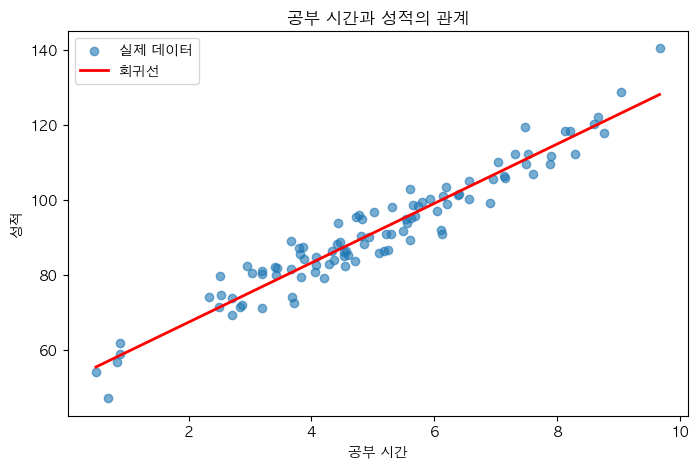

In [24]:
# 아래를 수행해 보세요:
# [문제 11] 여기에 코드를 작성해주세요.
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df11[['study_time']], df11['score'])

slope = model.coef_[0]
intercept = model.intercept_
print(f"기울기: {slope:.2f}, 절편: {intercept:.2f}")

plt.figure(figsize=(8,5))
plt.scatter(df11['study_time'], df11['score'], alpha=0.6, label='실제 데이터')

x_range = np.linspace(df11['study_time'].min(), df11['study_time'].max(), 100).reshape(-1, 1)
y_pred = model.predict(x_range)
plt.plot(x_range, y_pred, color='red', linewidth=2, label='회귀선')

plt.title('공부 시간과 성적의 관계')
plt.xlabel('공부 시간')
plt.ylabel('성적')
plt.legend()
plt.show()


**🧠 데이터를 어떻게 읽을까요?**

1. 공부 시간이 성적에 어떤 영향을 주었나요?
2. 회귀선은 데이터를 잘 설명하고 있나요?
3. 이 회귀식을 현실에 적용할 수 있을까요?
4. 선형 회귀분석은 언제 활용할 수 있을까요?

### 데이터를 어떻게 읽을까요?
#### [문제 11] 여기에 의견을 작성해주세요.

1. 공부 시간이 늘어날수록 성적이 올라갔다.
2. 회귀선은 데이터를 잘 설명하고있따.
3. 현실에서는 공부시간뿐만 아니라 수면시간, 학습방법 등 다른 요인이 많기 때문에 현실에 적용하기는 힘들다.
4. 선형회귀는 두 변수 간 관계의 방향이나 크기를 나타내고, 관계가 대략 직선일때 활용할 수 있다.

# 문제 12. A/B 테스트 해석

**📘 문제**

- 두 그룹의 전환율 차이를 계산하고 해석해봅시다.

In [25]:
# 데이터 생성
np.random.seed(606)
group_a = np.random.binomial(1, 0.12, 1000)
group_b = np.random.binomial(1, 0.15, 1000)

**📌 아래를 수행해 보세요:**

1. A 그룹과 B 그룹의 전환 데이터를 살펴봅니다.
2. 각 그룹의 전환율을 계산하고, 차이를 확인합니다.
3. 이 차이가 우연인지, 의미 있는 차이인지 생각해 봅시다.

In [26]:
# 아래를 수행해 보세요:
# [문제 12] 여기에 코드를 작성해주세요.
rate_a = group_a.mean()
rate_b = group_b.mean()
diff = rate_b - rate_a

print(f"A 그룹 전환율: {rate_a:.4f}")
print(f"B 그룹 전환율: {rate_b:.4f}")
print(f"차이: {diff:.4f}")

# 비율 z-검정으로 통계적 유의성 확인
n1, n2 = len(group_a), len(group_b)
p_pool = (group_a.sum() + group_b.sum()) / (n1 + n2)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z = diff / se
print(f"z-통계량: {z:.3f}  (|z| > 1.96이면 통계적으로 유의)")


A 그룹 전환율: 0.1310
B 그룹 전환율: 0.1330
차이: 0.0020
z-통계량: 0.132  (|z| > 1.96이면 통계적으로 유의)


**🧠 데이터를 어떻게 읽을까요?**

1. 두 그룹의 전환율 차이는 얼마나 되나요?
2. 차이가 '의미 있다'는 건 무엇을 뜻하나요?
3. 이 실험 결과로 어떤 결정을 내릴 수 있을까요?
4. A/B 테스트는 현실에서 어떻게 쓰일까요?

### 데이터를 어떻게 읽을까요?
#### [문제 12] 여기에 의견을 작성해주세요.

1. 두 그룹의 전환율 차이는 0.0020이다.
2. 차이가 의미있다는 건 이 차이가 우연이 아니라 실제 차이를 반영한다고 볼 근거가 있다는 뜻이다.
3. 이 실험 결과로로 B가 더 낫다. 라고 결정을 내릴수도 있지만, 우연일 수도 있는 가능성이 있기때문에 표본을 늘리거나 재검증이 필요하다.
4. 가격정책, 마케팅 문구 효과 검증 등에 쓰인다.